# Demo
This notebook aims to demo some functionality for new members onboarding

## Remote simulator

In [2]:
from config_loader import CONFIG
from remote import PS5Remote, RemoteSimulator
from logger import Logger, LogLevels

remote = PS5Remote(Logger(identifier="remote"))
simulator = RemoteSimulator(remote)
simulator.run()
print("Simulation is running on a separate window")


17:33:55.642443 -> [   remote   ]    INFO    | Logger initialized, print:    INFO   , write to file:   DEBUG   
17:33:55.651217 -> [   remote   ]    INFO    | PS5 controller successfully connected
17:34:04.690952 -> [   remote   ]    INFO    | PS5 controller disconnected


SystemExit: 

c:\Users\romai\OneDrive - De Vinci\Bureau\Projets\Venvs\coupe_de_robotique\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Planification des taches

In [3]:
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

class TaskPlanner:
    def __init__(self, num_tasks, scores, service_times, travel_time_matrix, max_time, solve_limit_seconds=10):
        self.num_tasks = num_tasks
        self.scores = scores
        self.service_times = service_times
        self.travel_time_matrix = travel_time_matrix
        self.max_time = max_time
        self.num_nodes = num_tasks + 2  # Including start and end nodes
        self.start_node = 0
        self.end_node = num_tasks + 1
        self.solve_limit_seconds = solve_limit_seconds

        # Initialize routing index manager
        self.manager = pywrapcp.RoutingIndexManager(
            self.num_nodes, 1, [self.start_node], [self.end_node])

        # Create routing model
        self.routing = pywrapcp.RoutingModel(self.manager)

        # Register transit callback
        def transit_callback(from_index, to_index):
            from_node = self.manager.IndexToNode(from_index)
            to_node = self.manager.IndexToNode(to_index)
            
            if from_node == self.start_node or from_node == self.end_node:
                service_time = 0
            else:
                service_time = self.service_times[from_node - 1]
                
            return service_time + self.travel_time_matrix[from_node][to_node]

        transit_callback_index = self.routing.RegisterTransitCallback(transit_callback)

        # Add time dimension constraint
        self.routing.AddDimension(
            transit_callback_index,
            0,  # No slack
            self.max_time,  # Maximum time allowed
            True,  # Start cumul to zero
            "Time"
        )

        # Set penalties for disjunctions (prizes)
        for node in range(1, self.num_tasks + 1):
            index = self.manager.NodeToIndex(node)
            self.routing.AddDisjunction([index], self.scores[node - 1])

        # Set arc cost to transit callback (for routing logic)
        self.routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def solve(self, time_limit_seconds=None):
        search_parameters = pywrapcp.DefaultRoutingSearchParameters()
        search_parameters.first_solution_strategy = (
            routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
        )
        search_parameters.local_search_metaheuristic = (
            routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
        )
        if time_limit_seconds:
            search_parameters.time_limit.seconds = time_limit_seconds
        else:
            search_parameters.time_limit.seconds = self.solve_limit_seconds

        solution = self.routing.SolveWithParameters(search_parameters)

        if solution:
            route = []
            total_score = sum(self.scores) - solution.ObjectiveValue()
            time_dimension = self.routing.GetDimensionOrDie("Time")
            index = self.routing.Start(0)

            while not self.routing.IsEnd(index):
                node = self.manager.IndexToNode(index)
                route.append(node)
                index = solution.Value(self.routing.NextVar(index))
            
            route.append(self.manager.IndexToNode(index))
            total_time = solution.Min(time_dimension.CumulVar(self.routing.End(0)))

            return {
                "route": route,
                "total_score": total_score,
                "total_time": total_time
            }
        else:
            return {"message": "Aucune solution trouvée"}

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_graphs(travel_time_matrix, task_scores, optimal_path=None):
    num_nodes = len(travel_time_matrix)
    G = nx.DiGraph()
    
    # Add edges with travel time weights
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if travel_time_matrix[i][j] > 0:
                G.add_edge(i, j, weight=travel_time_matrix[i][j])
                G.add_edge(j, i, weight=travel_time_matrix[j][i])
    
    # Node positions for clearer display
    pos = nx.spring_layout(G, seed=42, k=0.5)  # Adjust 'k' to control node distance
    
    # Add task scores to corresponding nodes
    labels = {i: f"{i}:{task_scores[i-1]}" if 0 < i < num_nodes - 1 else str(i) for i in range(num_nodes)}
    
    plt.figure(figsize=(15, 5))
    
    if optimal_path:
        # Draw graph with optimal solution highlighted
        G_opt = nx.DiGraph()
        for i in range(len(optimal_path) - 1):
            G_opt.add_edge(optimal_path[i], optimal_path[i + 1], weight=travel_time_matrix[optimal_path[i]][optimal_path[i + 1]])
        
        plt.subplot(1, 2, 2)
        nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', edge_color='gray', node_size=1000, font_size=10)
        nx.draw_networkx_edges(G, pos, edgelist=G_opt.edges, edge_color='red', width=2)
        edge_labels_opt = {(i, j): travel_time_matrix[i][j] for i, j in G_opt.edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_opt)
        edge_labels = {(i, j): travel_time_matrix[i][j] for i, j in G.edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        plt.title("Graph with optimal solution highlighted")
    else:
        # Draw input graph
        plt.subplot(1, 2, 1)
        nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightblue', edge_color='gray', node_size=1000, font_size=10)
        edge_labels = {(i, j): travel_time_matrix[i][j] for i, j in G.edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        plt.title("Graph with optimal solution")
    
    plt.show()


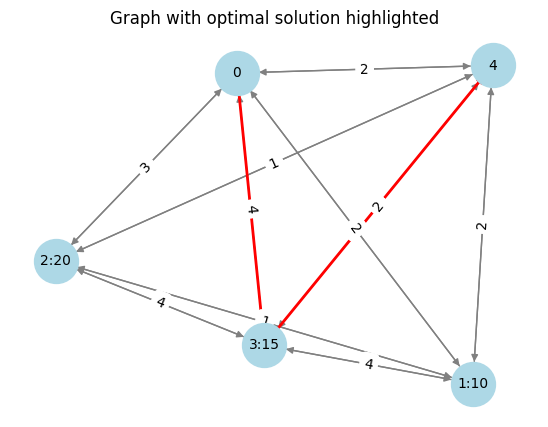

In [6]:
# Paramètres d'exemple
num_tasks = 3
scores = [10, 20, 15]
service_times = [5, 8, 3]
max_time = 10

# Matrice de temps de déplacement (inclut start et end)
travel_time_matrix = [
    [0, 2, 3, 4, 2],  # De start (0) aux autres
    [2, 0, 1, 4, 2],  # De tâche 1 aux autres
    [3, 1, 0, 4, 1],  # De tâche 2 aux autres
    [4, 4, 4, 0, 2],  # De tâche 3 aux autres
    [2, 2, 1, 2, 0]   # De end (4) aux autres
]

planner = TaskPlanner(num_tasks, scores, service_times, travel_time_matrix, max_time)
result = planner.solve(time_limit_seconds=1)
plot_graphs(travel_time_matrix, scores, result["route"])

# plot_graphs()

17:09:29.812806 -> [ Dummy Arena ] [  arena.py  :102]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
17:09:29.813817 -> [ Dummy Arena ] [  arena.py  :108]  WARNING   | The obstacle buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
17:09:29.866150 -> [ Dummy Grid Manager ] [decorators.py:41]   DEBUG    | [grid_manager] GridManager.__mark_zone(self=<arena.base_..., grid=<Grid width=..., polygon_to_mark=<POLYGON ((8..., walkable=False) executed in 0.045810s
17:09:29.868709 -> [ Dummy Grid Manager ] [decorators.py:41]   DEBUG    | [arena] GridManager.add_forbidden_static_zone(self=<arena.base_..., forbidden_zones=<POLYGON ((8...) executed in 0.048234s
17:09:29.945486 -> [ Dummy Grid Manager ] [decorators.py:41]   DEBUG    | [grid_manager] GridManager.__mark_zone(self=<arena.base_..., grid=<Grid width=..., polygon_to_mark=<POLYGON ((8..., walkable=False) execute

TypeError: Task.__init__() got an unexpected keyword argument 'execution_time'

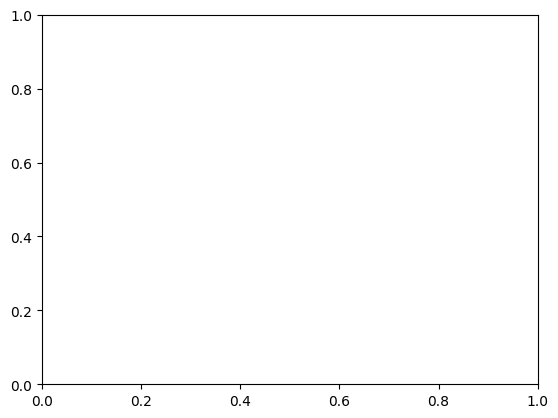

In [ ]:
from config_loader import CONFIG
from brains import MainBrain
from tasks import Task
import gc

brain = MainBrain.get_dummy_brain()
game_tasks = [
    Task(action_func=lambda:"action 1",start_func=lambda:print("action start 1"),name="task1", execution_time=10, score=5),
    Task(action_func=lambda:"action 1",start_func=lambda:print("action start 1"),name="task1", execution_time=10, score=5),
    Task(action_func=lambda:"action 1",start_func=lambda:print("action start 1"),name="task1", execution_time=10, score=5),
]
brain.game_tasks = game_tasks
brain.get_game_task_planification()